In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

生成训练数据和测试数据

In [ ]:
def generate_data(func, sample_size=1000, test_ratio=0.2):
    np.random.seed(42)
    X = np.random.uniform(-5, 5, (sample_size, 1))
    y = func(X)
    
    # 转换为PyTorch张量
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)
    
    # 分割数据集
    split = int(sample_size * (1 - test_ratio))
    return (X_tensor[:split], y_tensor[:split], 
            X_tensor[split:], y_tensor[split:])

目标函数

In [36]:
def target_function(x):
    return np.sin(x * 2) + 0.5 * x

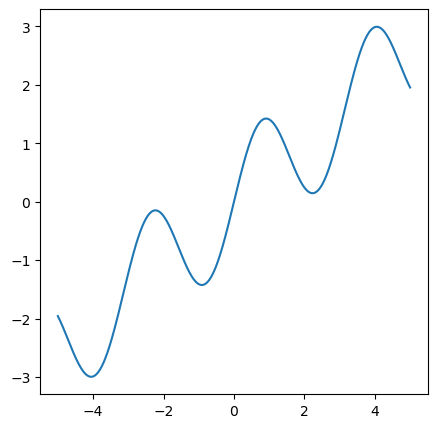

In [37]:
plt.figure(figsize=(5, 5))
x_vis = torch.linspace(-5, 5, 1000).reshape(-1, 1)
with torch.no_grad():
    y_pred = model(x_vis).numpy()
y_true = target_function(x_vis.numpy())
plt.plot(x_vis.numpy(), y_true)

构建Relu神经网络

In [42]:
class ReLUNet(nn.Module):
    def __init__(self, hidden_size=128):
        super(ReLUNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),  # 第二层
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )
        
        # 初始化权重
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        return self.net(x)

Epoch [0/5000], Loss: 4.2059
Epoch [500/5000], Loss: 0.1362
Epoch [1000/5000], Loss: 0.0017
Epoch [1500/5000], Loss: 0.0003
Epoch [2000/5000], Loss: 0.0003
Epoch [2500/5000], Loss: 0.0002
Epoch [3000/5000], Loss: 0.0002
Epoch [3500/5000], Loss: 0.0002
Epoch [4000/5000], Loss: 0.0005
Epoch [4500/5000], Loss: 0.0002

Test Loss: 0.0002


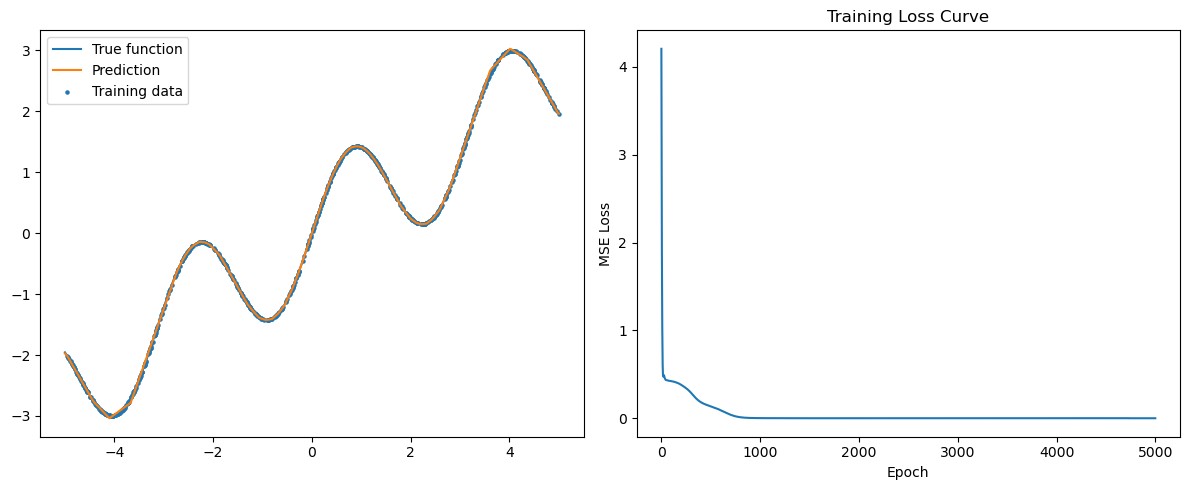

In [43]:
# 生成数据
X_train, y_train, X_test, y_test = generate_data(target_function)

# 初始化模型
model = ReLUNet(hidden_size=128)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 训练参数
epochs = 5000
losses = []

for epoch in range(epochs):
    # 前向传播
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    
    # 反向传播与优化
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # 记录损失
    losses.append(loss.item())
    
    if epoch % 500 == 0:
        print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.4f}')

# 测试集验证
with torch.no_grad():
    test_pred = model(X_test)
    test_loss = criterion(test_pred, y_test)
    print(f'\nTest Loss: {test_loss.item():.4f}')

# 可视化结果
plt.figure(figsize=(12, 5))

# 预测可视化
plt.subplot(1, 2, 1)
x_vis = torch.linspace(-5, 5, 1000).reshape(-1, 1)
with torch.no_grad():
    y_pred = model(x_vis).numpy()
y_true = target_function(x_vis.numpy())

plt.plot(x_vis.numpy(), y_true, label='True function')
plt.plot(x_vis.numpy(), y_pred, label='Prediction')
plt.scatter(X_train.numpy(), y_train.numpy(), s=5, label='Training data')
plt.legend()

# 损失曲线
plt.subplot(1, 2, 2)
plt.plot(losses)
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

plt.tight_layout()
plt.show()